In [1]:
import numpy as np
import pandas as pd
import os
import random
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
import torchvision.models as models
from torchvision.models import ResNet50_Weights
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import time
from tqdm import tqdm
import math
from sklearn.model_selection import train_test_split
import json
import os
import zipfile
from datetime import datetime

In [2]:
INPUT_PATH = Path('/kaggle/input/')
WORKING_PATH = Path('/kaggle/working/')

DATASET_PATH = INPUT_PATH / Path('celeba-aligned-and-cropped/')
IDENTITY_FILE_PATH = DATASET_PATH / Path('annotations/identity_CelebA.txt')
IMAGE_DIR_PATH = DATASET_PATH / Path('images')

SPLIT_METADATA_PATH = WORKING_PATH / Path('celeba_split_metadata.csv')

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

RANDOM_SEED = 42

# Формирование датасета
Для обучения модели для получения embedding-ов был использован полный датасет CelebA обрезанных и выровненных лиц знаменитостей - [ссылка](https://www.kaggle.com/datasets/magomedkurbandibirov/celeba-aligned-and-cropped/data)

In [3]:
identity_df = pd.read_csv(IDENTITY_FILE_PATH, sep=' ', header=None, names=['image_id', 'identity_id'])

identity_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202599 entries, 0 to 202598
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   image_id     202599 non-null  object
 1   identity_id  202599 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.1+ MB


In [48]:
Во время обучения выяснилось, что нескольких фоторафий описанных в `identity_CelebA.txt` нет в датасете, поэтому пришлось ~костылить~ фильтровать

SyntaxError: invalid syntax (1378258744.py, line 1)

Во время обучения выяснилось, что нескольких фоторафий описанных в `identity_CelebA.txt` нет в датасете, поэтому пришлось ~костылить~ фильтровать

In [20]:
def filter_existing_images(identity_df):    
    original_count = len(identity_df)
    print(f"\nOriginal records: {original_count:,}")

    identity_df['file_path'] = identity_df['image_id'].apply(
        lambda x: os.path.join(IMAGE_DIR_PATH, x)
    )

    identity_df['exists'] = identity_df['file_path'].apply(os.path.exists)
    
    missing_count = (~identity_df['exists']).sum()

    filtered_df = identity_df[identity_df['exists']].copy()
    filtered_df = filtered_df.drop(['exists', 'file_path'], axis=1)
    
    print(f"Filtering completed")
    print(f"  Removed: {original_count - len(filtered_df):,} records")
    print(f"  Remaining: {len(filtered_df):,} records")
    
    return filtered_df

identity_df = filter_existing_images(identity_df)


Original records: 202,599
Filtering completed
  Removed: 2 records
  Remaining: 202,597 records


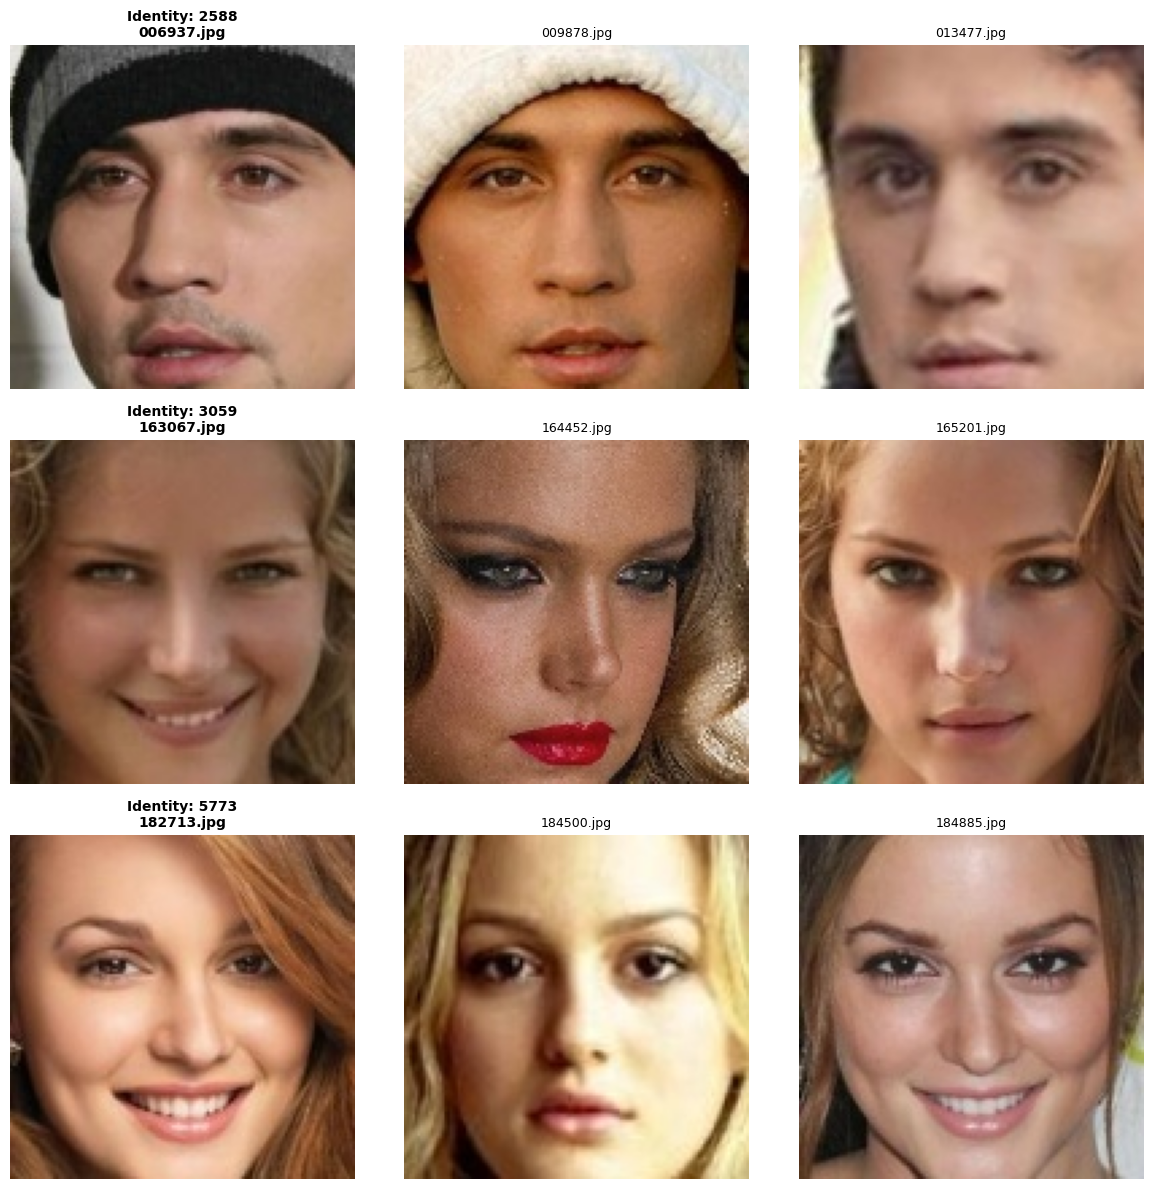

In [21]:
identity_counts = identity_df['identity_id'].value_counts()
identities_with_3plus = identity_counts[identity_counts >= 3].index.tolist()

random.seed(RANDOM_SEED)
selected_identities = random.sample(identities_with_3plus, min(3, len(identities_with_3plus)))

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for row_idx, identity_id in enumerate(selected_identities):
    identity_images = identity_df[identity_df['identity_id'] == identity_id]['image_id'].tolist()

    selected_images = identity_images[:3]
    
    for col_idx, img_name in enumerate(selected_images):
        img_path = IMAGE_DIR_PATH / img_name
        
        if img_path.exists():
            img = Image.open(img_path)
            axes[row_idx, col_idx].imshow(img)
            axes[row_idx, col_idx].axis('off')

            if col_idx == 0:
                axes[row_idx, col_idx].set_title(
                    f'Identity: {identity_id}\n{img_name}', 
                    fontsize=10, 
                    fontweight='bold'
                )
            else:
                axes[row_idx, col_idx].set_title(img_name, fontsize=9)
        else:
            axes[row_idx, col_idx].text(
                0.5, 0.5, 
                'Image not found', 
                ha='center', 
                va='center'
            )
            axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.show()

In [22]:
def create_train_val_test_split_celeba(
    identity_df,
    output_csv=SPLIT_METADATA_PATH,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    min_images_per_identity=10,
    random_seed=42
):
    """    
    Для каждого человека:
    - 70% его фото → train
    - 15% его фото → val
    - 15% его фото → test
    """
    df = identity_df.copy()
    if 'image_id' in df.columns:
        df = df.rename(columns={'image_id': 'filename'})
    
    df['full_path'] = df['filename'].apply(
        lambda x: os.path.join(IMAGE_DIR_PATH, x)
    )
    
    # Фильтрация по минимальному количеству
    identity_counts = df['identity_id'].value_counts()
    valid_identities = identity_counts[identity_counts >= min_images_per_identity].index
    df = df[df['identity_id'].isin(valid_identities)].reset_index(drop=True)

    train_data = []
    val_data = []
    test_data = []
    
    for identity in df['identity_id'].unique():
        # Все изображения этого человека
        person_df = df[df['identity_id'] == identity]
        
        num_images = len(person_df)
        
        # Вычисляем размеры splits для этого человека
        num_train = max(1, int(num_images * train_ratio))
        num_val = max(1, int(num_images * val_ratio))
        num_test = num_images - num_train - num_val
        
        # Если test получился 0, перераспределяем
        if num_test == 0 and num_images >= 3:
            num_train -= 1
            num_test = 1

        person_df_shuffled = person_df.sample(frac=1, random_state=random_seed).reset_index(drop=True)
        
        train_part = person_df_shuffled.iloc[:num_train]
        val_part = person_df_shuffled.iloc[num_train:num_train+num_val]
        test_part = person_df_shuffled.iloc[num_train+num_val:]
        
        train_data.append(train_part)
        val_data.append(val_part)
        if len(test_part) > 0:
            test_data.append(test_part)

    train_df = pd.concat(train_data).reset_index(drop=True)
    val_df = pd.concat(val_data).reset_index(drop=True)
    test_df = pd.concat(test_data).reset_index(drop=True) if test_data else pd.DataFrame()
    
    train_df['split'] = 'train'
    val_df['split'] = 'val'
    if len(test_df) > 0:
        test_df['split'] = 'test'

    final_df = pd.concat([train_df, val_df, test_df]).reset_index(drop=True)

    print("РЕЗУЛЬТАТЫ SPLIT")
    
    for split in ['train', 'val', 'test']:
        split_df = final_df[final_df['split'] == split]
        if len(split_df) == 0:
            continue
        
        print(f"\n{split.upper()}:")
        print(f"  Изображений: {len(split_df)} ({len(split_df)/len(final_df)*100:.1f}%)")
        print(f"  Уникальных людей: {split_df['identity_id'].nunique()}")
        print(f"  Среднее изображений/человек: {len(split_df)/split_df['identity_id'].nunique():.2f}")

    final_df.to_csv(output_csv, index=False)
    print(f"\nМетаданные сохранены: {output_csv}")
    print("="*70)
    
    return final_df

In [23]:
class CelebAFaceRecognitionDataset(Dataset):   
    def __init__(self, metadata_csv, split='train', transform=None):
        """
        Args:
            metadata_csv: CSV файл с метаданными
            split: 'train', 'val', или 'test'
            transform: Трансформации
        """
        df = pd.read_csv(metadata_csv)

        df = df[df['split'] == split]
        
        self.df = df.reset_index(drop=True)
        self.transform = transform

        full_df = pd.read_csv(metadata_csv)
        unique_identities = sorted(full_df['identity_id'].unique())
        self.id_to_label = {id_: idx for idx, id_ in enumerate(unique_identities)}
        
        self.num_classes = len(unique_identities)

        current_identities = self.df['identity_id'].nunique()

        print(f"Images: {len(self.df)}")
        print(f"Identities in this split: {current_identities}")
        print(f"Total identities (all splits): {self.num_classes}")
    
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img_path = row['full_path']
        
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.id_to_label[row['identity_id']]
        
        return image, label


In [24]:
split_metadata_df = create_train_val_test_split_celeba(
    identity_df=identity_df,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    min_images_per_identity=10,
    random_seed=RANDOM_SEED
)

РЕЗУЛЬТАТЫ SPLIT

TRAIN:
  Изображений: 133169 (68.8%)
  Уникальных людей: 8369
  Среднее изображений/человек: 15.91

VAL:
  Изображений: 25542 (13.2%)
  Уникальных людей: 8369
  Среднее изображений/человек: 3.05

TEST:
  Изображений: 34856 (18.0%)
  Уникальных людей: 8369
  Среднее изображений/человек: 4.16

Метаданные сохранены: /kaggle/working/celeba_split_metadata.csv


In [25]:
train_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = CelebAFaceRecognitionDataset(
    metadata_csv=SPLIT_METADATA_PATH,
    split='train',
    transform=train_transforms
)

val_dataset = CelebAFaceRecognitionDataset(
    metadata_csv=SPLIT_METADATA_PATH,
    split='val',
    transform=val_transforms
)

test_dataset = CelebAFaceRecognitionDataset(
    metadata_csv=SPLIT_METADATA_PATH,
    split='test',
    transform=val_transforms
)

Images: 133169
Identities in this split: 8369
Total identities (all splits): 8369
Images: 25542
Identities in this split: 8369
Total identities (all splits): 8369
Images: 34856
Identities in this split: 8369
Total identities (all splits): 8369


In [27]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Реализация модели и ArcFace
Ниже представлены реализация ArcFace слоя и самой модели.

В качестве базовой модели использовалась предобученная `EfficientNet_b0`. В модели указаны два режима обучения: `ArcFace`(s = 64, m = 0,5) и `CrossEntropy`. Размер embedding-а - 512

Отдельный класс `FaceRecognitionTrainer` отвечает за обучение, хранение истории и визуализацию результатов обучения. В качестве оптимизатора использован `AdamW`.

In [28]:
class ArcFaceLoss(nn.Module):
    def __init__(self, num_classes, embedding_size=512, s=30.0, m=0.50):
        """
        Args:
            num_classes: Количество уникальных людей в датасете
            embedding_size: Размерность эмбеддинга (512)
            s: Scale parameter (30.0 - 64.0)
            m: Angular margin в радианах (0.5 ≈ 28.6°)
        """
        super(ArcFaceLoss, self).__init__()
        
        self.num_classes = num_classes
        self.embedding_size = embedding_size
        self.s = s
        self.m = m

        self.weight = nn.Parameter(torch.FloatTensor(num_classes, embedding_size))
        nn.init.xavier_uniform_(self.weight)
        
        # Предвычисленные констант для оптимизации
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.threshold = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m
    
    def forward(self, embeddings, labels):
        """
        Args:
            embeddings: (batch_size, embedding_size) - из backbone
            labels: (batch_size,) - ground truth метки
            
        Returns:
            loss: scalar ArcFace loss
        """
        # Нормализация эмбеддингов, приводим все векторы к единичной длине
        embeddings = F.normalize(embeddings, p=2, dim=1)

        # Нормализация весов классов
        weight_norm = F.normalize(self.weight, p=2, dim=1)

        # Вычисление cos(θ) через скалярное произведение: cos = embeddings · weight^T
        cos = F.linear(embeddings, weight_norm)

        # Вычисление sin(θ) из cos(θ) через тождество: sin²(θ) + cos²(θ) = 1
        sin = torch.sqrt(1.0 - torch.pow(cos, 2))

        # Вычисление cos(θ + m) через тождество: cos(θ + m) = cos(θ)·cos(m) - sin(θ)·sin(m)
        phi = cos * self.cos_m - sin * self.sin_m

        # Если θ + m > π, используем cos(θ) - mm
        phi = torch.where(cos > self.threshold, phi, cos - self.mm)

        # Создание one-hot вектора для целевого класса
        one_hot = torch.zeros_like(cos)
        one_hot.scatter_(1, labels.view(-1, 1).long(), 1)

        # Применение margin только к целевому классу
        output = (one_hot * phi) + ((1.0 - one_hot) * cos)

        # Масштабирование scale параметром s
        output *= self.s

        return F.cross_entropy(output, labels)

    def get_logits(self, embeddings):
        embeddings = F.normalize(embeddings, p=2, dim=1)
        weight_norm = F.normalize(self.weight, p=2, dim=1)

        return self.s * F.linear(embeddings, weight_norm)


In [29]:
class FaceRecognitionModel(nn.Module):
    def __init__(self, num_classes, embedding_size=512, loss_type='arcface', freeze_first_n_layers=0):
        """
        Args:
            num_classes: Количество уникальных людей
            embedding_size: Размерность эмбеддинга
            loss_type: 'arcface' или 'ce' (CrossEntropy)
        """
        super(FaceRecognitionModel, self).__init__()
        
        self.loss_type = loss_type
        
        weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
        self.backbone = models.efficientnet_b0(weights=weights)

        self.backbone.classifier = nn.Identity()
        backbone_output_size = 1280

        if freeze_first_n_layers > 0:
            for i, block in enumerate(self.backbone.features):
                if i < freeze_first_n_layers:
                    for param in block.parameters():
                        param.requires_grad = False

        self.bottleneck = nn.Sequential(
            nn.Linear(backbone_output_size, 512),
            nn.BatchNorm1d(512),
        )

        # Loss layer в зависимости от типа
        if loss_type == 'arcface':
            self.loss_fn = ArcFaceLoss(
                num_classes=num_classes,
                embedding_size=embedding_size,
                s=64.0,
                m=0.50
            )
        elif loss_type == 'ce':
            self.classifier = nn.Linear(embedding_size, num_classes)
            self.loss_fn = nn.CrossEntropyLoss()
        else:
            raise ValueError(f"Unknown loss_type: {loss_type}")
        
    def forward(self, images, labels=None):
        features = self.backbone(images)

        embeddings = self.bottleneck(features)
    
        logits = None

        if self.loss_type == 'ce':
            logits = self.classifier(embeddings)
        elif self.loss_type == 'arcface':
            logits = self.loss_fn.get_logits(embeddings)
            
        if self.training and labels is not None:
            if self.loss_type == 'ce':
                loss = self.loss_fn(logits, labels)
            else:
                loss = self.loss_fn(embeddings, labels)
    
            return embeddings, logits, loss
    
        return embeddings, logits

In [53]:
class FaceRecognitionTrainer:
    def __init__(
        self,
        model,
        train_loader,
        val_loader,
        device='cuda',
        num_epochs=50,
        checkpoint_dir='checkpoints',
        experiment_name='face_recognition'
    ):
        """
        Args:
            model: FaceRecognitionModel
            train_loader: DataLoader для обучения
            val_loader: DataLoader для валидации
            device: 'cuda' или 'cpu'
            num_epochs: Количество эпох
            checkpoint_dir: Папка для сохранения checkpoints
            experiment_name: Название эксперимента
        """
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.device = device
        self.num_epochs = num_epochs
        
        # Создаем папку для эксперимента
        self.experiment_dir = os.path.join(checkpoint_dir, experiment_name)
        os.makedirs(self.experiment_dir, exist_ok=True)
        
        # Добавляем параметры loss layer
        if model.loss_type == 'arcface':
            self.optimizer = torch.optim.AdamW([
                {'params': model.backbone.parameters(), 'lr': 1e-4},
                {'params': model.bottleneck.parameters(), 'lr': 5e-4},
                {'params': model.loss_fn.parameters(), 'lr': 5e-4},
            ], weight_decay=5e-4)
        else:
            self.optimizer = torch.optim.AdamW(
                list(model.backbone.parameters()) +
                list(model.bottleneck.parameters()) +
                list(model.classifier.parameters()),
                lr=1e-4,
                weight_decay=1e-4
            )

        self.scheduler = torch.optim.lr_scheduler.StepLR(self.optimizer, step_size=10, gamma=0.1)
        
        self.history = {
            'train_loss': [],
            'train_top1': [],
            'train_top5': [],
            'train_top10': [],
            'val_loss': [],
            'val_top1': [],
            'val_top5': [],
            'val_top10': [],
            'lr': []
        }
        
        self.best_val_top1 = 0.0
        self.best_epoch = 0
    
    def train_one_epoch(self, epoch):
        self.model.train()
        
        total_loss = 0
        total_metrics = {'top1': 0, 'top5': 0, 'top10': 0}
        num_batches = 0
        
        pbar = tqdm(self.train_loader, desc=f'Epoch {epoch}/{self.num_epochs}')
        
        for images, labels in pbar:
            images = images.to(self.device)
            labels = labels.to(self.device)
            
            embeddings, logits, loss = self.model(images, labels)

            with torch.no_grad():
                metrics = self.compute_accuracy(logits, labels)
                for k in metrics:
                    total_metrics[k] += metrics[k]
            
            # Backward pass
            self.optimizer.zero_grad()
            
            loss.backward()
            self.optimizer.step()
            
            # Update metrics
            total_loss += loss.item()
            num_batches += 1

            current_lr = self.optimizer.param_groups[0]['lr']
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'top1': f'{metrics["top1"]:.4f}',
                'top5': f'{metrics["top5"]:.4f}',
                'lr': f'{current_lr:.6f}'
            })
        
        avg_metrics = {k: v / num_batches for k, v in total_metrics.items()}
        avg_metrics['loss'] = total_loss / num_batches
        
        return avg_metrics
    
    def val_one_epoch(self):
        self.model.eval()
        
        total_loss = 0
        total_metrics = {'top1': 0, 'top5': 0, 'top10': 0}
        num_batches = 0
        
        with torch.no_grad():
            for images, labels in tqdm(self.val_loader, desc='Validation'):
                images = images.to(self.device)
                labels = labels.to(self.device)
                
                # Forward pass
                if self.model.training:
                    self.model.eval()
                
                embeddings, logits = self.model(images)
                
                if self.model.loss_type == 'arcface':
                    loss = self.model.loss_fn(embeddings, labels)
                else:
                    loss = self.model.loss_fn(logits, labels)
                
                metrics = self.compute_accuracy(logits, labels)
                for k in metrics:
                    total_metrics[k] += metrics[k]
                
                total_loss += loss.item()
                num_batches += 1
        
        avg_loss = total_loss / num_batches
        avg_metrics = {k: v / num_batches for k, v in total_metrics.items()}
        
        result_metrics = {
            'loss': avg_loss,
            'top1': avg_metrics['top1'],
            'top5': avg_metrics['top5'],
            'top10': avg_metrics['top10']
        }
        
        return result_metrics

    def train(self):
        print("STARTING TRAINING")
        
        for epoch in range(1, self.num_epochs + 1):
            epoch_start_time = time.time()

            current_lr = self.optimizer.param_groups[0]['lr']
            self.history['lr'].append(current_lr)
            
            print(f"\nEpoch {epoch}/{self.num_epochs}")
            print(f"Learning Rate: {current_lr:.6f}")
            
            train_metrics = self.train_one_epoch(epoch)
            
            val_metrics = self.val_one_epoch()
            
            self.history['train_loss'].append(train_metrics['loss'])
            self.history['train_top1'].append(train_metrics['top1'])
            self.history['train_top5'].append(train_metrics['top5'])
            self.history['train_top10'].append(train_metrics['top10'])
            
            self.history['val_loss'].append(val_metrics['loss'])
            self.history['val_top1'].append(val_metrics['top1'])
            self.history['val_top5'].append(val_metrics['top5'])
            self.history['val_top10'].append(val_metrics['top10'])
            
            epoch_time = time.time() - epoch_start_time
            
            print(f"\nEpoch {epoch} Summary:")
            print(f"  Train Loss: {train_metrics['loss']:.4f}")
            print(f"  Train Top-1: {train_metrics['top1']:.4f} | Top-5: {train_metrics['top5']:.4f} | Top-10: {train_metrics['top10']:.4f}")
            print(f"  Val Loss: {val_metrics['loss']:.4f}")
            print(f"  Val Top-1: {val_metrics['top1']:.4f} | Top-5: {val_metrics['top5']:.4f} | Top-10: {val_metrics['top10']:.4f}")

            print(f"  Time: {epoch_time:.2f}s")

            current_top1 = val_metrics['top1']
            if current_top1 > self.best_val_top1:
                self.best_val_top1 = current_top1
                self.best_epoch = epoch
                best_path = self.save_checkpoint(
                    epoch, val_metrics, 'best_model.pth'
                )
                print(f"  ★ New best model! Top-1: {self.best_val_top1:.4f}")

            self.scheduler.step()

        print("TRAINING COMPLETED")
        print(f"Best Epoch: {self.best_epoch}")
        print(f"Best Validation Top-1: {self.best_val_top1:.4f} ({self.best_val_top1*100:.2f}%)")
        
        self.save_checkpoint(self.num_epochs, val_metrics, 'final_model.pth')
        self.plot_history('final_history.png')
        
        # Save history as JSON
        history_path = os.path.join(self.experiment_dir, 'history.json')
        with open(history_path, 'w') as f:
            json.dump(self.history, f, indent=2)
        
        print(f"History saved: {history_path}")

    def compute_accuracy(self, logits, labels):
        """
        Returns:
            dict с метриками: top1, top5, top10
        """

        top1_acc = (logits.argmax(dim=1) == labels).float().mean().item()

        _, top5_predictions = torch.topk(logits, k=min(5, logits.size(1)), dim=1)
        top5_correct = 0
        for i, label in enumerate(labels):
            if label in top5_predictions[i]:
                top5_correct += 1
        top5_acc = top5_correct / labels.size(0)

        _, top10_predictions = torch.topk(logits, k=min(10, logits.size(1)), dim=1)
        top10_correct = 0
        for i, label in enumerate(labels):
            if label in top10_predictions[i]:
                top10_correct += 1
        top10_acc = top10_correct / labels.size(0)
        
        return {
            'top1': top1_acc,
            'top5': top5_acc,
            'top10': top10_acc
        }
        
    def save_checkpoint(self, epoch, metrics, filename):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'metrics': metrics,
            'history': self.history,
            'loss_type': self.model.loss_type
        }
        
        filepath = os.path.join(self.experiment_dir, filename)
        torch.save(checkpoint, filepath)
        
        return filepath
    
    def plot_history(self, save_name='training_history.png', show=False):
        fig, axes = plt.subplots(2, 2, figsize=(18, 10))
        axes = axes.flatten()
        
        # 1. Loss
        axes[0].plot(self.history['train_loss'], label='Train', linewidth=2)
        axes[0].plot(self.history['val_loss'], label='Val', linewidth=2)
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title('Loss')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
        
        # 2. Top-1 Accuracy
        axes[1].plot(self.history['train_top1'], label='Train', linewidth=2)
        axes[1].plot(self.history['val_top1'], label='Val', linewidth=2)
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Top-1 Accuracy')
        axes[1].set_title('Top-1 Accuracy')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        # 3. Top-5 Accuracy
        axes[2].plot(self.history['train_top5'], label='Train', linewidth=2, color='green')
        axes[2].plot(self.history['val_top5'], label='Val', linewidth=2, color='lightgreen')
        axes[2].set_xlabel('Epoch')
        axes[2].set_ylabel('Top-5 Accuracy')
        axes[2].set_title('Top-5 Accuracy')
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        
        # 4. Top-10 Accuracy
        axes[3].plot(self.history['train_top10'], label='Train', linewidth=2, color='purple')
        axes[3].plot(self.history['val_top10'], label='Val', linewidth=2, color='violet')
        axes[3].set_xlabel('Epoch')
        axes[3].set_ylabel('Top-10 Accuracy')
        axes[3].set_title('Top-10 Accuracy')
        axes[3].legend()
        axes[3].grid(True, alpha=0.3)
        
        plt.tight_layout()
        if show:
            plt.show()
        else:
            save_path = os.path.join(self.experiment_dir, save_name)
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            plt.close()
    
    def test(self, test_loader):
        self.model.eval()
    
        total_loss = 0
        total_metrics = {'top1': 0, 'top5': 0, 'top10': 0}
        num_batches = 0
        
        with torch.no_grad():
            for images, labels in tqdm(test_loader, desc='Testing'):
                images = images.to(self.device)
                labels = labels.to(self.device)
    
                embeddings, logits = self.model(images)
    
                if self.model.loss_type == 'arcface':
                    loss = self.model.loss_fn(embeddings, labels)
                else:
                    loss = self.model.loss_fn(logits, labels)
    
                metrics = self.compute_accuracy(logits, labels)
                for k in metrics:
                    total_metrics[k] += metrics[k]
                
                total_loss += loss.item()
                num_batches += 1
    
        avg_loss = total_loss / num_batches
        avg_metrics = {k: v / num_batches for k, v in total_metrics.items()}
    
        test_results = {
            'loss': avg_loss,
            'top1_accuracy': avg_metrics['top1'],
            'top5_accuracy': avg_metrics['top5'],
            'top10_accuracy': avg_metrics['top10'],
        }

        print("TEST RESULTS")
        
        print("\nClassification Metrics:")
        print(f"  Loss: {test_results['loss']:.4f}")
        print(f"  Top-1 Accuracy: {test_results['top1_accuracy']:.4f} ({test_results['top1_accuracy']*100:.2f}%)")
        print(f"  Top-5 Accuracy: {test_results['top5_accuracy']:.4f} ({test_results['top5_accuracy']*100:.2f}%)")
        print(f"  Top-10 Accuracy: {test_results['top10_accuracy']:.4f} ({test_results['top10_accuracy']*100:.2f}%)")
        
        return test_results

# Обучение и валидация модели
Было обучено две модели(ArcFace и CE) ниже представленный промежуточные и финальные результаты после 20-ти эпох.

(Каждый раз сохраняется лучшая модель по top1-accuracy)

In [56]:
model_ce = FaceRecognitionModel(
    num_classes=train_dataset.num_classes,
    embedding_size=512,
    loss_type='ce'
)

In [57]:
trainer_ce = FaceRecognitionTrainer(
    model=model_ce,
    train_loader=train_loader,
    val_loader=val_loader,
    device='cuda',
    num_epochs=20,
    checkpoint_dir='experiments',
    experiment_name='crossentropy'
)

In [58]:
trainer_ce.train()

STARTING TRAINING

Epoch 1/20
Learning Rate: 0.000100


Validation: 100%|██████████| 400/400 [00:24<00:00, 16.52it/s]



Epoch 1 Summary:
  Train Loss: 8.2990
  Train Top-1: 0.0081 | Top-5: 0.0252 | Top-10: 0.0401
  Val Loss: 7.1329
  Val Top-1: 0.0373 | Top-5: 0.1029 | Top-10: 0.1479
  Time: 255.93s
  ★ New best model! Top-1: 0.0373

Epoch 2/20
Learning Rate: 0.000100


Validation: 100%|██████████| 400/400 [00:19<00:00, 20.87it/s]



Epoch 2 Summary:
  Train Loss: 6.2463
  Train Top-1: 0.1097 | Top-5: 0.2331 | Top-10: 0.3070
  Val Loss: 5.1534
  Val Top-1: 0.2283 | Top-5: 0.4125 | Top-10: 0.4975
  Time: 257.27s
  ★ New best model! Top-1: 0.2283

Epoch 3/20
Learning Rate: 0.000100


...


Epoch 18 Summary:
  Train Loss: 0.0146
  Train Top-1: 0.9986 | Top-5: 1.0000 | Top-10: 1.0000
  Val Loss: 1.2713
  Val Top-1: 0.7772 | Top-5: 0.8776 | Top-10: 0.9028
  Time: 259.03s
  ★ New best model! Top-1: 0.7772

Epoch 19/20
Learning Rate: 0.000010


Validation: 100%|██████████| 400/400 [00:18<00:00, 21.53it/s]



Epoch 19 Summary:
  Train Loss: 0.0137
  Train Top-1: 0.9987 | Top-5: 1.0000 | Top-10: 1.0000
  Val Loss: 1.2709
  Val Top-1: 0.7784 | Top-5: 0.8766 | Top-10: 0.9028
  Time: 258.43s
  ★ New best model! Top-1: 0.7784

Epoch 20/20
Learning Rate: 0.000010


Validation: 100%|██████████| 400/400 [00:18<00:00, 22.06it/s]



Epoch 20 Summary:
  Train Loss: 0.0129
  Train Top-1: 0.9988 | Top-5: 1.0000 | Top-10: 1.0000
  Val Loss: 1.2629
  Val Top-1: 0.7801 | Top-5: 0.8785 | Top-10: 0.9037
  Time: 258.03s
  ★ New best model! Top-1: 0.7801
TRAINING COMPLETED
Best Epoch: 20
Best Validation Top-1: 0.7801 (78.01%)
History saved: experiments/crossentropy/history.json


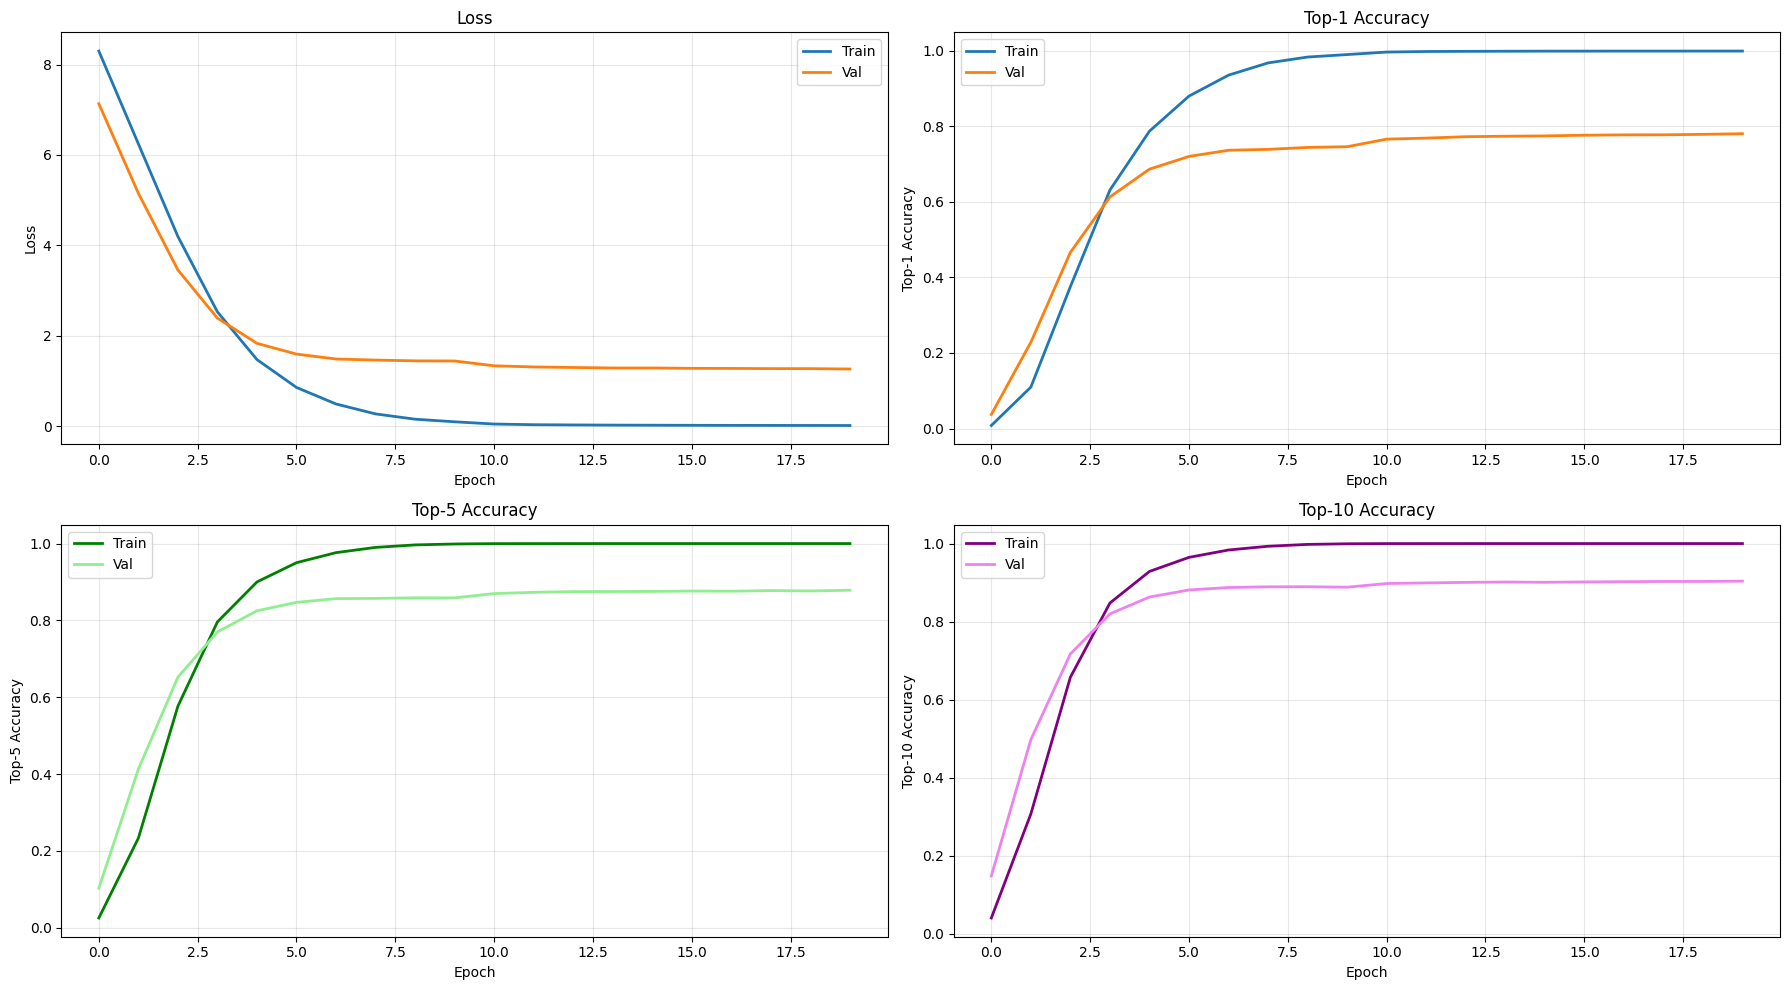

In [59]:
trainer_ce.plot_history(show=True)

In [60]:
_ = trainer_ce.test(test_loader)

Testing: 100%|██████████| 545/545 [00:30<00:00, 18.08it/s]

TEST RESULTS

Classification Metrics:
  Loss: 1.3313
  Top-1 Accuracy: 0.7688 (76.88%)
  Top-5 Accuracy: 0.8693 (86.93%)
  Top-10 Accuracy: 0.8975 (89.75%)


In [63]:
model_arcface = FaceRecognitionModel(
    num_classes=train_dataset.num_classes,
    embedding_size=512,
    loss_type='arcface'
)

In [64]:
trainer_arcface = FaceRecognitionTrainer(
    model=model_arcface,
    train_loader=train_loader,
    val_loader=val_loader,
    device='cuda',
    num_epochs=20,
    checkpoint_dir='experiments',
    experiment_name='arcface'
)

In [65]:
trainer_arcface.train()

STARTING TRAINING

Epoch 1/20
Learning Rate: 0.000100


Validation: 100%|██████████| 400/400 [00:18<00:00, 21.61it/s]



Epoch 1 Summary:
  Train Loss: 39.7457
  Train Top-1: 0.0739 | Top-5: 0.1417 | Top-10: 0.1810
  Val Loss: 35.7778
  Val Top-1: 0.2768 | Top-5: 0.4395 | Top-10: 0.5155
  Time: 263.06s
  ★ New best model! Top-1: 0.2768

Epoch 2/20
Learning Rate: 0.000100


Validation: 100%|██████████| 400/400 [00:18<00:00, 21.57it/s]



Epoch 2 Summary:
  Train Loss: 31.7369
  Train Top-1: 0.5184 | Top-5: 0.6886 | Top-10: 0.7481
  Val Loss: 29.5565
  Val Top-1: 0.6070 | Top-5: 0.7468 | Top-10: 0.7914
  Time: 263.89s
  ★ New best model! Top-1: 0.6070

Epoch 3/20
Learning Rate: 0.000100


...


Epoch 18 Summary:
  Train Loss: 7.9285
  Train Top-1: 0.9806 | Top-5: 0.9883 | Top-10: 0.9900
  Val Loss: 15.6068
  Val Top-1: 0.8855 | Top-5: 0.9314 | Top-10: 0.9428
  Time: 263.99s
  ★ New best model! Top-1: 0.8855

Epoch 19/20
Learning Rate: 0.000010


Validation: 100%|██████████| 400/400 [00:24<00:00, 16.63it/s]



Epoch 19 Summary:
  Train Loss: 7.8414
  Train Top-1: 0.9809 | Top-5: 0.9885 | Top-10: 0.9902
  Val Loss: 15.5668
  Val Top-1: 0.8860 | Top-5: 0.9313 | Top-10: 0.9432
  Time: 269.39s
  ★ New best model! Top-1: 0.8860

Epoch 20/20
Learning Rate: 0.000010


Validation: 100%|██████████| 400/400 [00:28<00:00, 14.23it/s]



Epoch 20 Summary:
  Train Loss: 7.7624
  Train Top-1: 0.9815 | Top-5: 0.9886 | Top-10: 0.9904
  Val Loss: 15.5640
  Val Top-1: 0.8860 | Top-5: 0.9307 | Top-10: 0.9427
  Time: 272.44s
TRAINING COMPLETED
Best Epoch: 19
Best Validation Top-1: 0.8860 (88.60%)
History saved: experiments/arcface/history.json


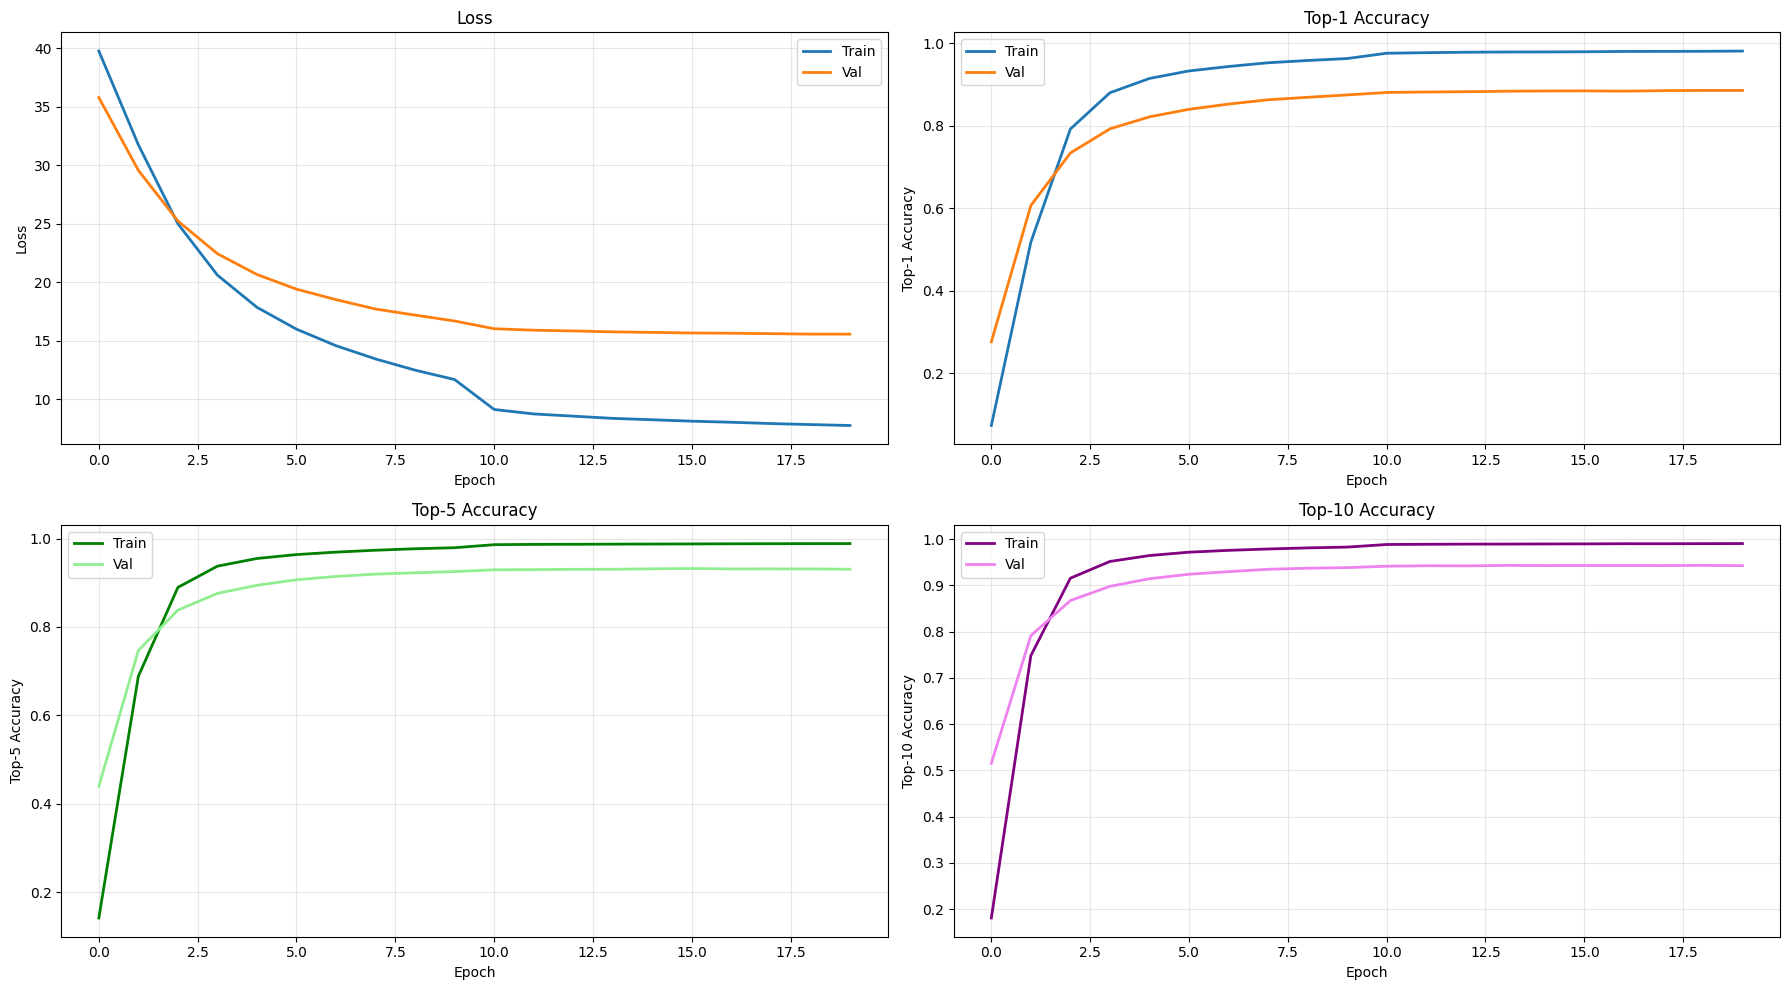

In [66]:
trainer_arcface.plot_history(show=True)

In [67]:
_ = trainer_arcface.test(test_loader)

Testing: 100%|██████████| 545/545 [00:33<00:00, 16.07it/s]

TEST RESULTS

Classification Metrics:
  Loss: 15.8795
  Top-1 Accuracy: 0.8794 (87.94%)
  Top-5 Accuracy: 0.9276 (92.76%)
  Top-10 Accuracy: 0.9392 (93.92%)


In [68]:
def create_zip_archive(source_dir, output_path=None, compression=zipfile.ZIP_DEFLATED):
    if output_path is None:
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        dirname = os.path.basename(source_dir.rstrip('/'))
        output_path = f'{dirname}_{timestamp}.zip'

    if not os.path.exists(source_dir):
        raise FileNotFoundError(f"Directory not found: {source_dir}")

    total_files = 0
    total_size = 0
    
    with zipfile.ZipFile(output_path, 'w', compression) as zipf:
        for root, dirs, files in os.walk(source_dir):
            for file in files:
                file_path = os.path.join(root, file)

                arcname = os.path.relpath(file_path, os.path.dirname(source_dir))
    
                zipf.write(file_path, arcname)
    
                file_size = os.path.getsize(file_path)
                total_files += 1
                total_size += file_size
                
                if total_files % 10 == 0:
                    print(f"  Archived {total_files} files ({total_size / 1024 / 1024:.2f} MB)...")

    archive_size = os.path.getsize(output_path)
    compression_ratio = (1 - archive_size / total_size) * 100 if total_size > 0 else 0
    
    print(f"\n✓ Archive created successfully!")
    print(f"  Files archived: {total_files}")
    print(f"  Location: {output_path}")
    
    return output_path

archive_path = create_zip_archive(
    source_dir='/kaggle/working/experiments',
    output_path='/kaggle/working/experiments_backup.zip'
)


✓ Archive created successfully!
  Files archived: 8
  Location: /kaggle/working/experiments_backup.zip


# Вывод

В результате сравнения двух моделей: с `ArcFace` и `CE` можно сделать вывод, что `ArcFace` больше подходит для задачи Face-Recognition.

Результаты инференса для модели с `CrossEntropy`:
- Top-1 Accuracy: 0.7688 (76.88%)
- Top-5 Accuracy: 0.8693 (86.93%)
- Top-10 Accuracy: 0.8975 (89.75%)

Результаты инференса для модели с `ArcFace`:
- Top-1 Accuracy: 0.8794 (87.94%)
- Top-5 Accuracy: 0.9276 (92.76%)
- Top-10 Accuracy: 0.9392 (93.92%)